# Comprobación general

Cuaderno que tiene como objetivo llevar a cabo una comparación de los distintos algoritmos de búsqueda utilizados en el proyecto.

## 1.- CDF Global

Primero obtenemos los datos de los distintos json con resultados

In [1]:
import json
import os
import math
import re

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

resultados_dir = "resultados/CDF/"
resultados = {}

for filename in os.listdir(resultados_dir):
    if filename.endswith(".json"):
        with open(os.path.join(resultados_dir, filename)) as json_file:
            resultados[filename[:-5]] = json.load(json_file)

# bf-expanding, bf-lawnmower, ldfs-heur, ldfs-miope
colors = ["#5B75A4", "#A45B99", "#5BA466", "#A48A5B"]
linestyles = ["solid", "dashed", "dashdot", "dotted"]

Ahora que ya tenemos todos los resultados obtenidos anteriormente podemos empezar con la comparación detallada.


### CDF de error con tiempo en referencia

### CDF de error con distancia acumulada

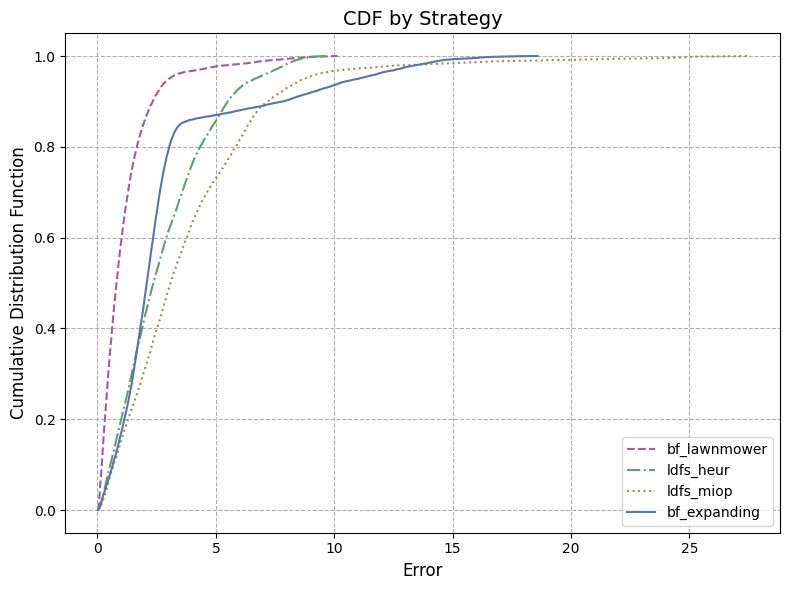

In [2]:
plt.style.use('default')
# bf-lawnmower
bf_lawnmower_runs = resultados["resultados_bf_lawnmower"]
bf_lawnmower_errors = np.concatenate([np.array(run["telemetry_error_sorted"]) for run in bf_lawnmower_runs])
bf_lawnmower_errors_sorted = np.sort(bf_lawnmower_errors)
bf_lawnmower_cdf = np.arange(1, len(bf_lawnmower_errors_sorted)+1) / len(bf_lawnmower_errors_sorted)

# bf-expanding
bf_expanding_runs = resultados["resultados_bf_expanding"]
bf_expanding_errors = np.concatenate([np.array(run["telemetry_error_sorted"]) for run in bf_expanding_runs])
bf_expanding_errors_sorted = np.sort(bf_expanding_errors)
bf_expanding_cdf = np.arange(1, len(bf_expanding_errors_sorted)+1) / len(bf_expanding_errors_sorted)

# ldfs-heur
ldfs_heur_runs = resultados["resultados_ldfs_heur"]
ldfs_heur_errors = np.concatenate([np.array(run["telemetry_error_sorted"]) for run in ldfs_heur_runs])
ldfs_heur_errors_sorted = np.sort(ldfs_heur_errors)
ldfs_heur_cdf = np.arange(1, len(ldfs_heur_errors_sorted)+1) / len(ldfs_heur_errors_sorted)

# ldfs-miope
ldfs_miope_runs = resultados["resultados_ldfs_miope"]
ldfs_miope_errors = np.concatenate([np.array(run["telemetry_error_sorted"]) for run in ldfs_miope_runs])
ldfs_miope_errors_sorted = np.sort(ldfs_miope_errors)
ldfs_miope_cdf = np.arange(1, len(ldfs_miope_errors_sorted)+1) / len(ldfs_miope_errors_sorted)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(bf_lawnmower_errors_sorted, bf_lawnmower_cdf, color="#A45B99", linestyle="dashed", label="bf_lawnmower")
ax.plot(ldfs_heur_errors_sorted, ldfs_heur_cdf, color="#5BA466", linestyle="dashdot", label="ldfs_heur")
ax.plot(ldfs_miope_errors_sorted, ldfs_miope_cdf, color="#A48A5B", linestyle="dotted", label="ldfs_miop")
ax.plot(bf_expanding_errors_sorted, bf_expanding_cdf, color='#5B75A4', linestyle='solid', label="bf_expanding")
ax.set_xlabel('Error', fontsize=12)
ax.set_ylabel('Cumulative Distribution Function', fontsize=12)
ax.set_title('CDF by Strategy', fontsize=14)
ax.legend(loc='lower right', frameon=True)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.savefig(r"D:\Imagenes\tfg\CDF_escenario1.pdf", format='pdf')
plt.show()

## 2.- Error cuadrático medio

En primer lugar vemos el error calculado cuando se agrega el tiempo a la trayectoria de referencia.

In [3]:
errores_medios = {}
plt.style.use('default')
for nombre_algoritmo, ejecuciones in resultados.items():
    suma_este = 0
    suma_norte = 0
    suma_altura = 0
    suma_total = 0
    n = len(ejecuciones)

    for ejecucion in ejecuciones:
        e = ejecucion["error_east_time"]
        nrt = ejecucion["error_north_time"]
        h = ejecucion["error_height_time"]

        suma_este += abs(e)
        suma_norte += abs(nrt)
        suma_altura += abs(h)

        error_total = math.sqrt(e**2 + nrt**2 + h**2)
        suma_total += error_total

    errores_medios[nombre_algoritmo] = {
        "media_este": suma_este / n,
        "media_norte": suma_norte / n,
        "media_altura": suma_altura / n,
        "media_total": ((suma_este / n)+(suma_norte / n)+(suma_altura / n)) / 3
    }

# Crear DataFrame a partir del diccionario
df_rmse = pd.DataFrame.from_dict(errores_medios, orient='index')
# O si usas Jupyter o IPython para que se vea bonito:
df_rmse

,media_este,media_norte,media_altura,media_total
resultados_bf_expanding,2.631858,2.803485,0.017699,1.817681
resultados_bf_lawnmower,1.509684,0.386534,0.028849,0.641689
resultados_ldfs_heur,2.410588,2.393748,0.018049,1.607462
resultados_ldfs_miope,3.510337,3.341685,0.022676,2.291566


## 3.- DTW

In [5]:
dtw_dir = "resultados/DTW/"
dtw_resultados = []
plt.style.use('default')
for filename in os.listdir(dtw_dir):
    if filename.endswith(".json"):
        path = os.path.join(dtw_dir, filename)
        with open(path, 'r') as json_file:
            ejecuciones = json.load(json_file)

        match = re.search(r"resultados_(.+)_dtw\.json", path)

        df = pd.DataFrame(ejecuciones)
        algorithm = match.group(1)
        df['algorithm'] = algorithm
        dtw_resultados.append(df)

df = pd.concat(dtw_resultados, ignore_index=True)

In [6]:
resumen = df.groupby('algorithm').agg({
    'mean_dtw': ['mean', 'std'],
    'median_dtw': ['mean', 'std'],
    'max_dtw': ['mean', 'std'],
    'std_dtw': ['mean', 'std'],
    'p90_dtw': ['mean', 'std'],
    'iqr_dtw': ['mean', 'std'],
    'total_dtw': ['mean', 'std']
}).reset_index()

print(resumen)


      algorithm  mean_dtw           median_dtw             max_dtw            \
                     mean       std       mean       std      mean       std   
0  bf_expanding  0.081006  0.009676   0.070230  0.006612  0.459902  0.170720   
1  bf_lawnmower  0.108813  0.028390   0.075320  0.015465  0.616124  0.186059   
2     ldfs_heur  0.190544  0.053050   0.137914  0.021146  1.105164  0.778749   
3    ldfs_miope  0.241547  0.061966   0.168769  0.015275  1.653860  0.873911   

    std_dtw             p90_dtw             iqr_dtw             total_dtw  \
       mean       std      mean       std      mean       std        mean   
0  0.051173  0.015719  0.139349  0.022866  0.055087  0.004073  244.269946   
1  0.102534  0.036816  0.229642  0.067625  0.058475  0.042242  328.973758   
2  0.162271  0.086108  0.426043  0.181707  0.175566  0.057426  609.051253   
3  0.218340  0.116541  0.515373  0.178079  0.236575  0.074592  774.233485   

               
          std  
0   29.378387  
1   86.2

Text(0.5, 0, 'Algorithm')

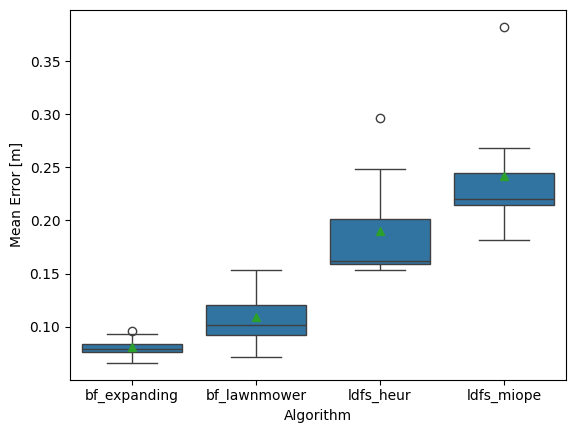

In [7]:
sns.boxplot(x="algorithm", y="mean_dtw", data=df, showmeans=True)
plt.ylabel('Mean Error [m]')
plt.xlabel('Algorithm')

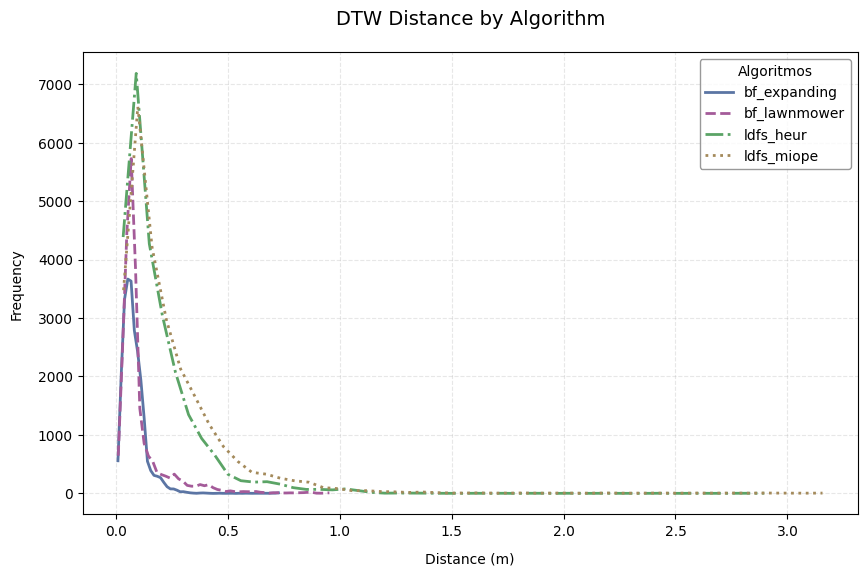

In [8]:
plt.figure(figsize=(10, 6))
plt.style.use('default')
for i, algoritmo in enumerate(df['algorithm'].unique()):
    try:
        distancias = np.concatenate(df[df['algorithm'] == algoritmo]['distances'].values)
        if len(distancias) == 0:
            raise ValueError
        counts, bins = np.histogram(distancias, bins=50)
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
        plt.plot(bin_centers, counts, label=algoritmo, color=colors[i], linestyle=linestyles[i], linewidth=2)
    except ValueError:
        print(f"¡Ojo! Datos vacíos para {algoritmo}")
        continue

# Personalización del gráfico
plt.title("DTW Distance by Algorithm", pad=20, fontsize=14)
plt.xlabel("Distance (m)", labelpad=10)
plt.ylabel("Frequency", labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)

legend = plt.legend(title="Algoritmos", frameon=True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')
plt.savefig(fr"D:\Imagenes\tfg\histograma_global1.pdf", format='pdf')
plt.show()

In [9]:
for i, algoritmo in enumerate(df['algorithm'].unique()):
    distancias = np.concatenate(df[df['algorithm'] == algoritmo]['distances'].values)

    color = colors[i % len(colors)]  # Para asegurarte de no salirte del rango

    # Calcular estadísticas
    stats = {
        "Mean": np.mean(distancias),
        "Median": np.median(distancias),
        "Min": np.min(distancias),
        "Max": np.max(distancias),
        "Std Dev": np.std(distancias),
        "IQR": np.percentile(distancias, 75) - np.percentile(distancias, 25),
        "90th Percentile": np.percentile(distancias, 90),
        "Num. points": len(distancias)
    }

    stats_text = "\n".join([f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}"
                            for k, v in stats.items()])

    fig, axs = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1.5]})

    # VIOLINPLOT
    sns.violinplot(y=distancias, inner="box", linewidth=1.2, color=color, ax=axs[0])
    axs[0].set_title("DTW Distance Distribution")
    axs[0].set_ylabel("DTW Distance (m)")
    axs[0].set_xlabel("")
    axs[0].text(
        0.95, 0.95,
        stats_text,
        transform=axs[0].transAxes,
        fontsize=9,
        bbox=dict(boxstyle="round", fc="white", alpha=0.85),
        ha="right", va="top"
    )

    mean = np.mean(distancias)
    axs[0].plot(0, mean, marker='o', color='white', markeredgecolor='black', markersize=6, zorder=5)

    # HISTOGRAMA
    axs[1].hist(distancias, bins=50, color=color, edgecolor="black")
    axs[1].set_title("Frequency of DTW Distance")
    axs[1].set_xlabel("DTW Distance (m)")
    axs[1].set_ylabel("Frequency")

    fig.suptitle(f"DTW Distance Distribution and Frequency: {algoritmo}", fontsize=14)
    plt.tight_layout()
    plt.savefig(fr"D:\Imagenes\tfg\{algoritmo}_violin_histogram.pdf", format='pdf')
    plt.close()

## 4.- Tiempo medio de detección

In [10]:
tiempos_deteccion = {}

for algoritmo, ejecuciones in resultados.items():
    suma_t = 0
    n = len(ejecuciones)

    for ejecucion in ejecuciones:
        tiempo = ejecucion["tiempo_deteccion"]

        suma_t += abs(tiempo)


    tiempos_deteccion[algoritmo] = {
        "tiempo_medio": suma_t / n,
    }

# Crear DataFrame a partir del diccionario
df_t = pd.DataFrame.from_dict(tiempos_deteccion, orient='index')
# O si usas Jupyter o IPython para que se vea bonito:
df_t

,tiempo_medio
resultados_bf_expanding,45.500
resultados_bf_lawnmower,149.250
resultados_ldfs_heur,38.375
resultados_ldfs_miope,183.000


## 5.- Distancia media recorrida

In [11]:
distancia_recorrida = {}

for algoritmo, ejecuciones in resultados.items():
    suma_d = 0
    n = len(ejecuciones)

    for ejecucion in ejecuciones:
        distancia = ejecucion["distancia-recorrida"]

        suma_d += abs(distancia)


    distancia_recorrida[algoritmo] = {
        "Distancia": round(suma_d / n, 4),
    }

# Crear DataFrame a partir del diccionario
df_d = pd.DataFrame.from_dict(distancia_recorrida, orient='index')
# O si usas Jupyter o IPython para que se vea bonito:
df_d

,Distancia
resultados_bf_expanding,47.6244
resultados_bf_lawnmower,211.1494
resultados_ldfs_heur,36.6983
resultados_ldfs_miope,199.8772
